# Data Inspection Notebook
Inspect the structure of ShapeNetSem rendered data and Amazon product data.

## 1. ShapeNetSem Rendered Data

In [1]:
import os
import cv2
import numpy as np
import OpenEXR
import Imath
import matplotlib.pyplot as plt
import pandas as pd
import lz4.frame
import pickle

%matplotlib inline

### 1.1 Folder Structure

In [2]:
OUTPUT_DIR = './code/dataset/output'
model_folders = sorted([d for d in os.listdir(OUTPUT_DIR) if os.path.isdir(os.path.join(OUTPUT_DIR, d))])
print(f"Total model folders: {len(model_folders)}")
print(f"\nFirst 5 model IDs:")
for m in model_folders[:5]:
    print(f"  {m}")

Total model folders: 8991

First 5 model IDs:
  1004f30be305f33d28a1548e344f0e2e
  100f39dce7690f59efb94709f30ce0d2
  101354f9d8dede686f7b08d9de913afe
  1018f01d42ae7fad52249d8432f6087e
  102273fdf8d1b90041fbc1e2da054acb


In [3]:
# Inspect one model folder
sample_model = model_folders[0]
sample_path = os.path.join(OUTPUT_DIR, sample_model)
files = sorted(os.listdir(sample_path))
print(f"Model: {sample_model}")
print(f"Files ({len(files)}):")
for f in files:
    size_kb = os.path.getsize(os.path.join(sample_path, f)) / 1024
    print(f"  {f:60s} {size_kb:8.1f} KB")

# Categorize files
png_files = [f for f in files if f.endswith('.png')]
exr_files = [f for f in files if f.endswith('.exr')]
print(f"\nPNG (RGB) files: {len(png_files)}")
print(f"EXR (Depth) files: {len(exr_files)}")
print(f"\nView suffixes:")
for png in png_files:
    suffix = png.replace(f"{sample_model}_", "").replace(".png", "")
    print(f"  {suffix}")

Model: 1004f30be305f33d28a1548e344f0e2e
Files (28):
  1004f30be305f33d28a1548e344f0e2e_back.png                       125.6 KB
  1004f30be305f33d28a1548e344f0e2e_back_depth0001.exr               5.0 KB
  1004f30be305f33d28a1548e344f0e2e_bottom.png                     181.9 KB
  1004f30be305f33d28a1548e344f0e2e_bottom_depth0001.exr            15.3 KB
  1004f30be305f33d28a1548e344f0e2e_front.png                      125.6 KB
  1004f30be305f33d28a1548e344f0e2e_front_depth0001.exr              5.0 KB
  1004f30be305f33d28a1548e344f0e2e_left.png                       125.6 KB
  1004f30be305f33d28a1548e344f0e2e_left_depth0001.exr               5.0 KB
  1004f30be305f33d28a1548e344f0e2e_r_000.png                      170.1 KB
  1004f30be305f33d28a1548e344f0e2e_r_000_depth0001.exr             10.5 KB
  1004f30be305f33d28a1548e344f0e2e_r_045.png                      178.6 KB
  1004f30be305f33d28a1548e344f0e2e_r_045_depth0001.exr             13.5 KB
  1004f30be305f33d28a1548e344f0e2e_r_090.png    

### 1.2 Inspect a Sample RGB Image (RGBA)

Image path: ./code/dataset/output/1004f30be305f33d28a1548e344f0e2e/1004f30be305f33d28a1548e344f0e2e_back.png
Shape: (480, 640, 4)
Dtype: uint8
Channels: BGRA
Value range: [0, 1]


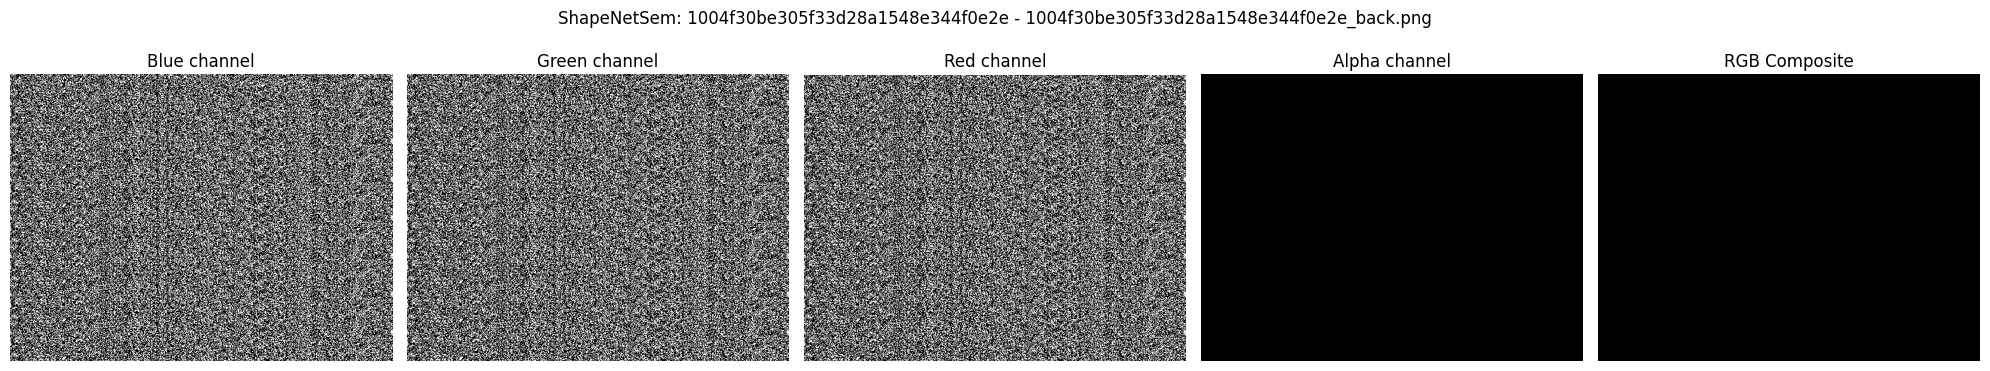

In [4]:
sample_png = os.path.join(sample_path, png_files[0])
img_rgba = cv2.imread(sample_png, cv2.IMREAD_UNCHANGED)
print(f"Image path: {sample_png}")
print(f"Shape: {img_rgba.shape}")
print(f"Dtype: {img_rgba.dtype}")
print(f"Channels: {'BGRA' if img_rgba.shape[2] == 4 else 'BGR'}")
print(f"Value range: [{img_rgba.min()}, {img_rgba.max()}]")

# Show RGBA channels
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
channel_names = ['Blue', 'Green', 'Red', 'Alpha']
for i, name in enumerate(channel_names):
    axes[i].imshow(img_rgba[:, :, i], cmap='gray')
    axes[i].set_title(f"{name} channel")
    axes[i].axis('off')

img_rgb = cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGB)
axes[4].imshow(img_rgb)
axes[4].set_title("RGB Composite")
axes[4].axis('off')
plt.suptitle(f"ShapeNetSem: {sample_model} - {png_files[0]}", fontsize=12)
plt.tight_layout()
plt.show()

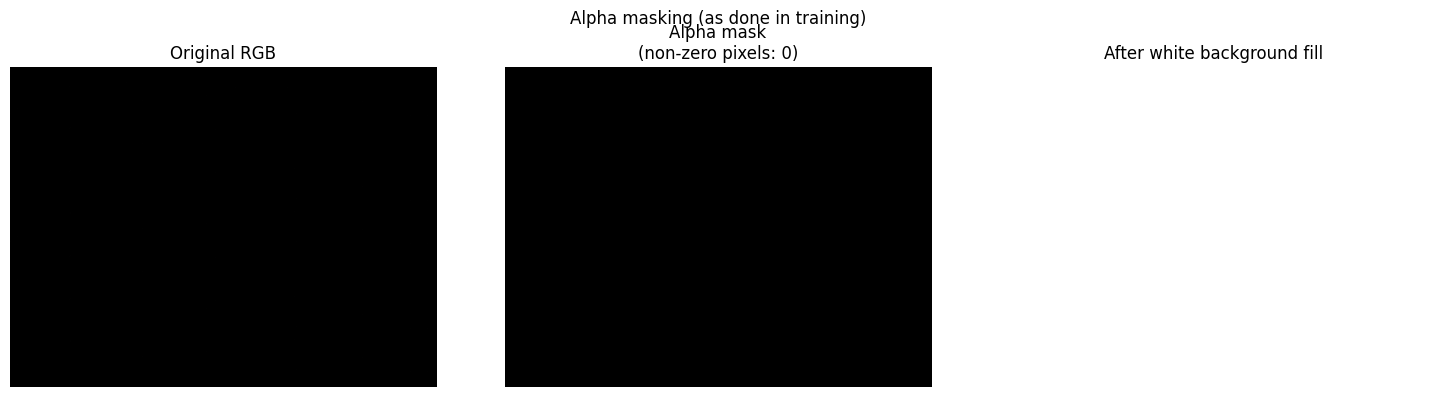

In [5]:
# Show what happens after alpha masking (white background) - as done in training
alpha = img_rgba[:, :, 3]
img_masked = cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGBA)
img_masked[alpha == 0] = (255, 255, 255, 0)
img_masked_rgb = img_masked[:, :, :3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGB))
axes[0].set_title("Original RGB")
axes[1].imshow(alpha, cmap='gray')
axes[1].set_title(f"Alpha mask\n(non-zero pixels: {np.count_nonzero(alpha)})")
axes[2].imshow(cv2.cvtColor(img_masked_rgb, cv2.COLOR_BGR2RGB))
axes[2].set_title("After white background fill")
for ax in axes:
    ax.axis('off')
plt.suptitle("Alpha masking (as done in training)", fontsize=12)
plt.tight_layout()
plt.show()

### 1.3 Inspect a Sample EXR Depth Map

In [6]:
def read_exr(file_path):
    """Read depth from EXR file (R channel)."""
    exr_file = OpenEXR.InputFile(file_path)
    dw = exr_file.header()['dataWindow']
    size = (dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1)
    pt = Imath.PixelType(Imath.PixelType.FLOAT)
    redstr = exr_file.channel('R', pt)
    red = np.frombuffer(redstr, dtype=np.float32)
    red.shape = (size[1], size[0])
    return red

sample_exr = os.path.join(sample_path, exr_files[0])
depth = read_exr(sample_exr)
print(f"Depth path: {sample_exr}")
print(f"Shape: {depth.shape}")
print(f"Dtype: {depth.dtype}")
print(f"Value range: [{depth.min():.4f}, {depth.max():.4f}]")
print(f"Non-zero pixels: {np.count_nonzero(depth)}")
print(f"Zero pixels: {np.count_nonzero(depth == 0)}")
print(f"Inf pixels: {np.count_nonzero(np.isinf(depth))}")
print(f"NaN pixels: {np.count_nonzero(np.isnan(depth))}")

Depth path: ./code/dataset/output/1004f30be305f33d28a1548e344f0e2e/1004f30be305f33d28a1548e344f0e2e_back_depth0001.exr
Shape: (480, 640)
Dtype: float32
Value range: [0.0000, 0.0000]
Non-zero pixels: 0
Zero pixels: 307200
Inf pixels: 0
NaN pixels: 0


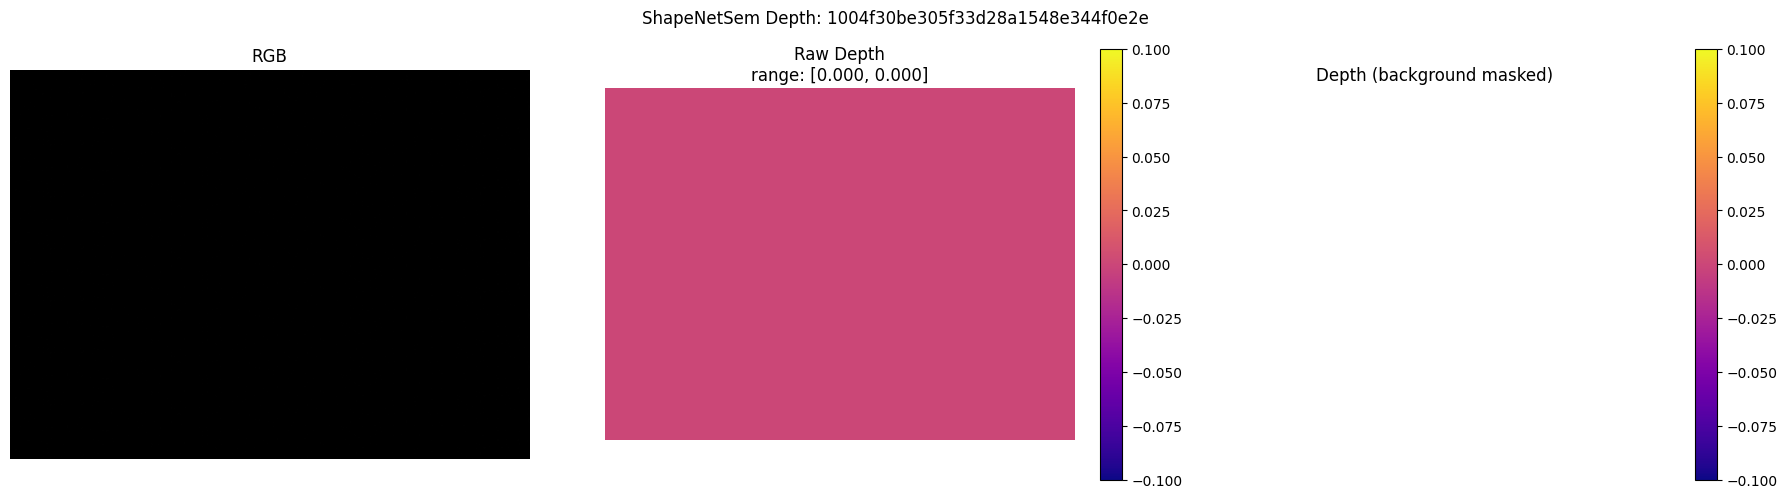

In [7]:
# Visualize depth map
depth_vis = depth.copy()
depth_vis[depth_vis == 0] = np.nan  # mask background for visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGB))
axes[0].set_title("RGB")
im1 = axes[1].imshow(depth, cmap='plasma')
axes[1].set_title(f"Raw Depth\nrange: [{depth.min():.3f}, {depth.max():.3f}]")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(depth_vis, cmap='plasma')
axes[2].set_title("Depth (background masked)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.axis('off')
plt.suptitle(f"ShapeNetSem Depth: {sample_model}", fontsize=12)
plt.tight_layout()
plt.show()

### 1.4 All 14 Views of One Model

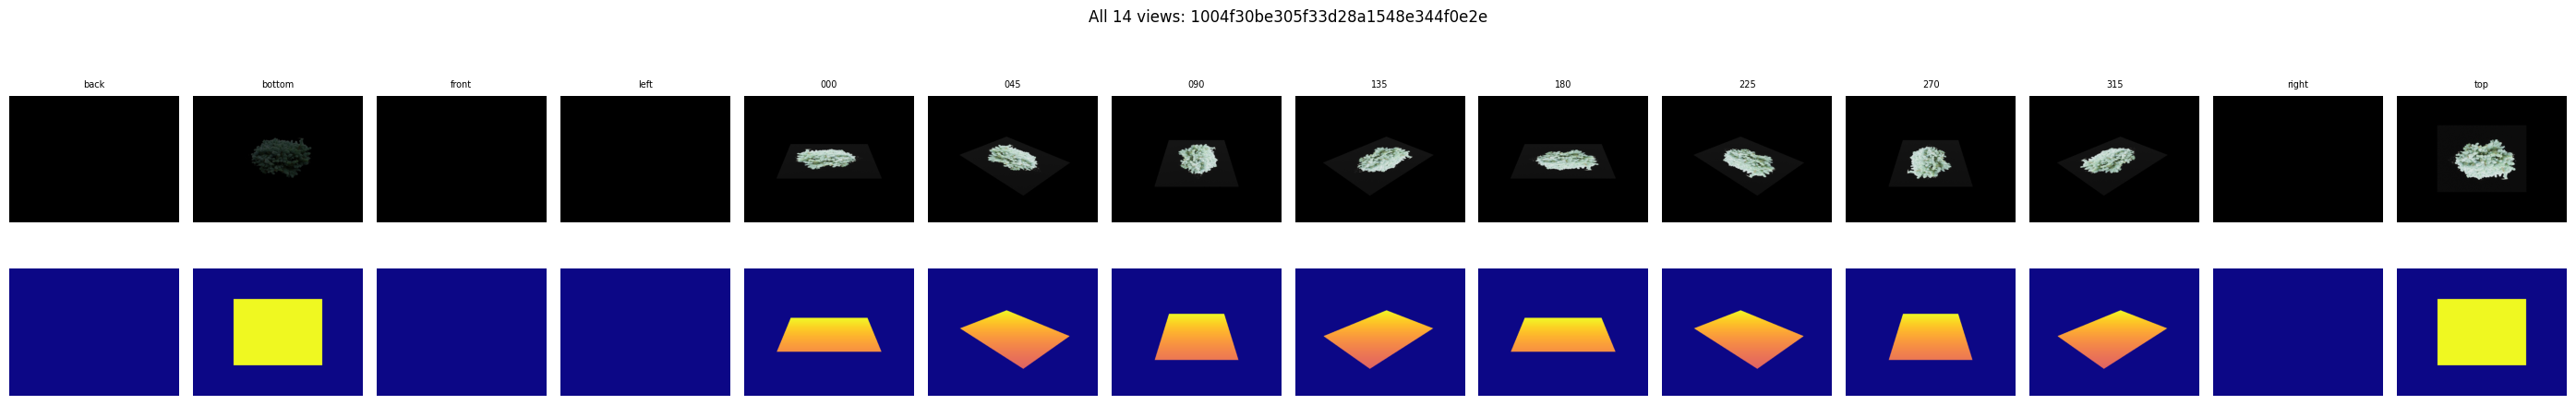

In [8]:
fig, axes = plt.subplots(2, 14, figsize=(28, 5))
for i, (png, exr) in enumerate(zip(png_files, exr_files)):
    img = cv2.imread(os.path.join(sample_path, png), cv2.IMREAD_UNCHANGED)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    dep = read_exr(os.path.join(sample_path, exr))
    
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(png.split('_')[-1].replace('.png', ''), fontsize=7)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(dep, cmap='plasma')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("RGB", fontsize=10)
axes[1, 0].set_ylabel("Depth", fontsize=10)
plt.suptitle(f"All 14 views: {sample_model}", fontsize=12)
plt.tight_layout()
plt.show()

### 1.5 Metadata & Normalization

In [9]:
metadata_path = './code/dataset/filenames/shapenetsem/metadata.txt'
metadata = pd.read_csv(metadata_path)
print(f"Metadata entries: {len(metadata)}")
print(f"Columns: {list(metadata.columns)}")
print(f"\nFirst 5 rows:")
metadata.head()

Metadata entries: 8940
Columns: ['fullId', 'aligned.dims']

First 5 rows:


,fullId,aligned.dims
0,wss.100f39dce7690f59efb94709f30ce0d2,"111.34567\,100.547745\,96.13275"
1,wss.101354f9d8dede686f7b08d9de913afe,"43.43313\,60.591843\,32.17259"
2,wss.1018f01d42ae7fad52249d8432f6087e,"78.23693\,4.360932\,18.058533"
3,wss.102273fdf8d1b90041fbc1e2da054acb,"18.514877\,71.531975\,48.62335"
4,wss.1022fe7dd03f6a4d4d5ad9f13ac9f4e7,"60.366123\,98.00925\,66.79712"


In [11]:
# Pick a sample model that exists in metadata (some models were filtered out for bad dims)
valid_ids = set(metadata['fullId'].str.replace('wss.', ''))
sample_model_valid = next(m for m in model_folders if m in valid_ids)
print(f"Using model: {sample_model_valid}")
print(f"(First folder '{sample_model}' was filtered out of metadata — likely had zero/bad dims)\n")

id_str = f'wss.{sample_model_valid}'
row = metadata.loc[metadata['fullId'] == id_str]
print(f"Model: {id_str}")
print(f"aligned.dims: {row['aligned.dims'].values[0]}")

dims_str = row['aligned.dims'].values[0]
dims = [float(d) / 100.0 for d in dims_str.split('\\,')]
diag = np.linalg.norm(dims)
print(f"\nDimensions (meters): {dims}")
print(f"Bounding box diagonal (normalization factor): {diag:.4f} m")

# Re-read depth for this valid model
sample_path_valid = os.path.join(OUTPUT_DIR, sample_model_valid)
valid_exr_files = sorted([f for f in os.listdir(sample_path_valid) if f.endswith('.exr')])
depth_valid = read_exr(os.path.join(sample_path_valid, valid_exr_files[0]))

print(f"\nRaw depth range: [{depth_valid.min():.4f}, {depth_valid.max():.4f}]")
depth_normalized = depth_valid / diag
print(f"Normalized depth range: [{depth_normalized.min():.4f}, {depth_normalized.max():.4f}]")
print(f"Max depth param (paper): 2.63")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(depth_valid, cmap='plasma')
axes[0].set_title(f"Raw depth (meters)\nrange: [{depth_valid.min():.3f}, {depth_valid.max():.3f}]")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(depth_normalized, cmap='plasma')
axes[1].set_title(f"Normalized depth (÷ {diag:.3f})\nrange: [{depth_normalized.min():.3f}, {depth_normalized.max():.3f}]")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Model: wss.1004f30be305f33d28a1548e344f0e2e


IndexError: index 0 is out of bounds for axis 0 with size 0

Models with valid dims: 8940
Min diagonal:  0.0503 m
Max diagonal:  62.7797 m
Mean diagonal: 1.3955 m
Median diagonal: 1.2121 m


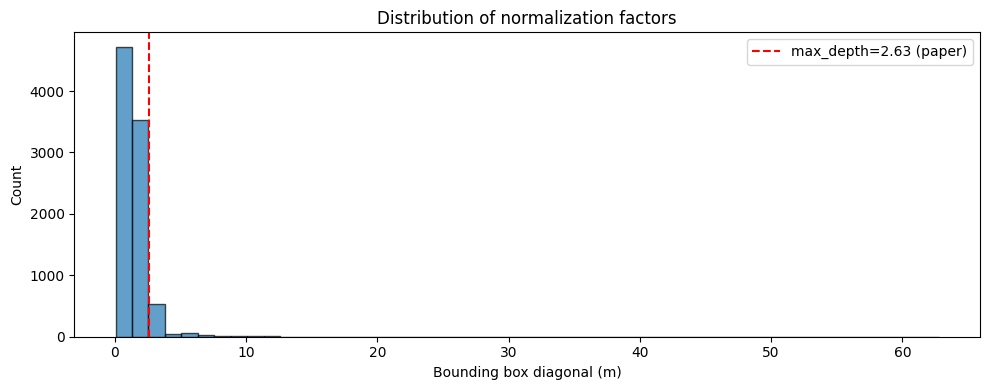

In [12]:
# Distribution of normalization factors across all models
all_diags = []
for _, row in metadata.iterrows():
    dims_str = row['aligned.dims']
    try:
        dims = [float(d) / 100.0 for d in dims_str.split('\\,')]
        all_diags.append(np.linalg.norm(dims))
    except:
        pass

print(f"Models with valid dims: {len(all_diags)}")
print(f"Min diagonal:  {min(all_diags):.4f} m")
print(f"Max diagonal:  {max(all_diags):.4f} m")
print(f"Mean diagonal: {np.mean(all_diags):.4f} m")
print(f"Median diagonal: {np.median(all_diags):.4f} m")

plt.figure(figsize=(10, 4))
plt.hist(all_diags, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=2.63, color='red', linestyle='--', label='max_depth=2.63 (paper)')
plt.xlabel('Bounding box diagonal (m)')
plt.ylabel('Count')
plt.title('Distribution of normalization factors')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Amazon Product Data (Image2Mass)

The Amazon data is at `datasets/amazon_data/` with individual `.pklz` files per product.
Each `.pklz` contains a dict with: `image_data`, `thickness_mask`, `weight`, `dimensions`.

### 2.1 Folder Structure

In [15]:
import lz4.block
from PIL import Image
from io import BytesIO

AMAZON_DIR = './datasets/amazon_data'

print("Amazon data folder structure:")
print(f"  {AMAZON_DIR}/")
for item in sorted(os.listdir(AMAZON_DIR)):
    full = os.path.join(AMAZON_DIR, item)
    if os.path.isdir(full):
        n_files = len(os.listdir(full))
        print(f"    {item}/  ({n_files} files)")
    else:
        size_kb = os.path.getsize(full) / 1024
        print(f"    {item}  ({size_kb:.1f} KB)")

Amazon data folder structure:
  ./datasets/amazon_data/
    .DS_Store  (6.0 KB)
    README  (1.5 KB)
    Screenshot 2026-02-27 at 11.44.25.png  (217.3 KB)
    read_data.py  (1.5 KB)
    test_data/  (1436 files)
    train_data/  (141951 files)
    val_data/  (6530 files)


### 2.2 Inspect a Single .pklz File

In [17]:
def load_pklz(filepath):
    """Load a .pklz file (lz4-compressed pickle)."""
    with open(filepath, 'rb') as fp:
        compressed = fp.read()
    decompressed = lz4.block.decompress(compressed)
    return pickle.loads(decompressed)

def pklz_image(encoded_image):
    """Decode image bytes to PIL Image -> numpy array."""
    return np.array(Image.open(BytesIO(encoded_image)))

# Load one sample from test_data
test_dir = os.path.join(AMAZON_DIR, 'test_data')
test_files = sorted(os.listdir(test_dir))
sample_file = test_files[0]
sample_path_amz = os.path.join(test_dir, sample_file)

record = load_pklz(sample_path_amz)

print(f"File: {sample_file}")
print(f"File size: {os.path.getsize(sample_path_amz) / 1024:.1f} KB")
print(f"\nRecord type: {type(record)}")
print(f"Record keys: {list(record.keys())}")
print()
for key, val in record.items():
    if key == 'image_data':
        img = pklz_image(val)
        print(f"  {key}: bytes -> image shape={img.shape}, dtype={img.dtype}")
    elif key == 'thickness_mask':
        if val is not None:
            mask = np.array(val) if not isinstance(val, np.ndarray) else val
            print(f"  {key}: shape={mask.shape}, dtype={mask.dtype}, range=[{mask.min()}, {mask.max()}]")
        else:
            print(f"  {key}: None")
    elif key == 'dimensions':
        print(f"  {key}: {val} (inches)")
    elif key == 'weight':
        print(f"  {key}: {val} lbs")
    else:
        print(f"  {key}: {val}")

File: 6530_ignition coil large.pklz
File size: 24.7 KB

Record type: <class 'dict'>
Record keys: ['dimensions', 'image_data', 'id', 'thickness_mask', 'weight']

  dimensions: ('4.00', '4.00', '4.00') (inches)
  image_data: bytes -> image shape=(512, 512, 3), dtype=uint8
  id: 6530
  thickness_mask: shape=(32, 32), dtype=float32, range=[0.0, 0.3731640875339508]
  weight: 2.00 lbs


/var/folders/w8/l3b5rp5n4vqdlhzzjgztff500000gq/T/ipykernel_92123/540533676.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(decompressed)


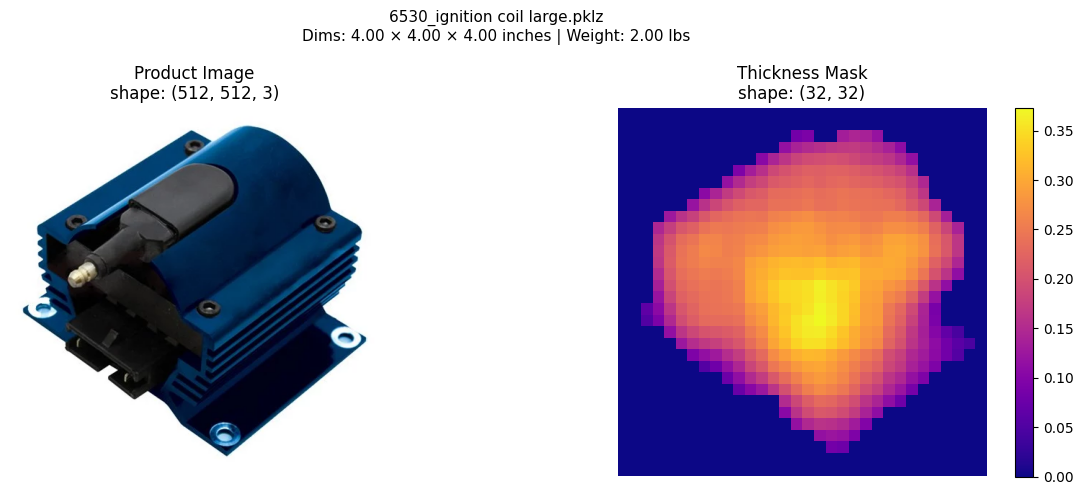

In [18]:
# Visualize the product
img = pklz_image(record['image_data'])
dims = record['dimensions']
weight = record['weight']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Product Image\nshape: {img.shape}")
axes[0].axis('off')

if record.get('thickness_mask') is not None:
    mask = np.array(record['thickness_mask']) if not isinstance(record['thickness_mask'], np.ndarray) else record['thickness_mask']
    im = axes[1].imshow(mask, cmap='plasma')
    axes[1].set_title(f"Thickness Mask\nshape: {mask.shape}")
    plt.colorbar(im, ax=axes[1], fraction=0.046)
else:
    axes[1].text(0.5, 0.5, 'No thickness mask', ha='center', va='center', fontsize=14)
axes[1].axis('off')

dim_str = ' × '.join(dims) + ' inches' if isinstance(dims, (list, tuple)) else str(dims)
plt.suptitle(f"{sample_file}\nDims: {dim_str} | Weight: {weight} lbs", fontsize=11)
plt.tight_layout()
plt.show()

### 2.3 Sample Products from Each Split

/var/folders/w8/l3b5rp5n4vqdlhzzjgztff500000gq/T/ipykernel_92123/540533676.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(decompressed)


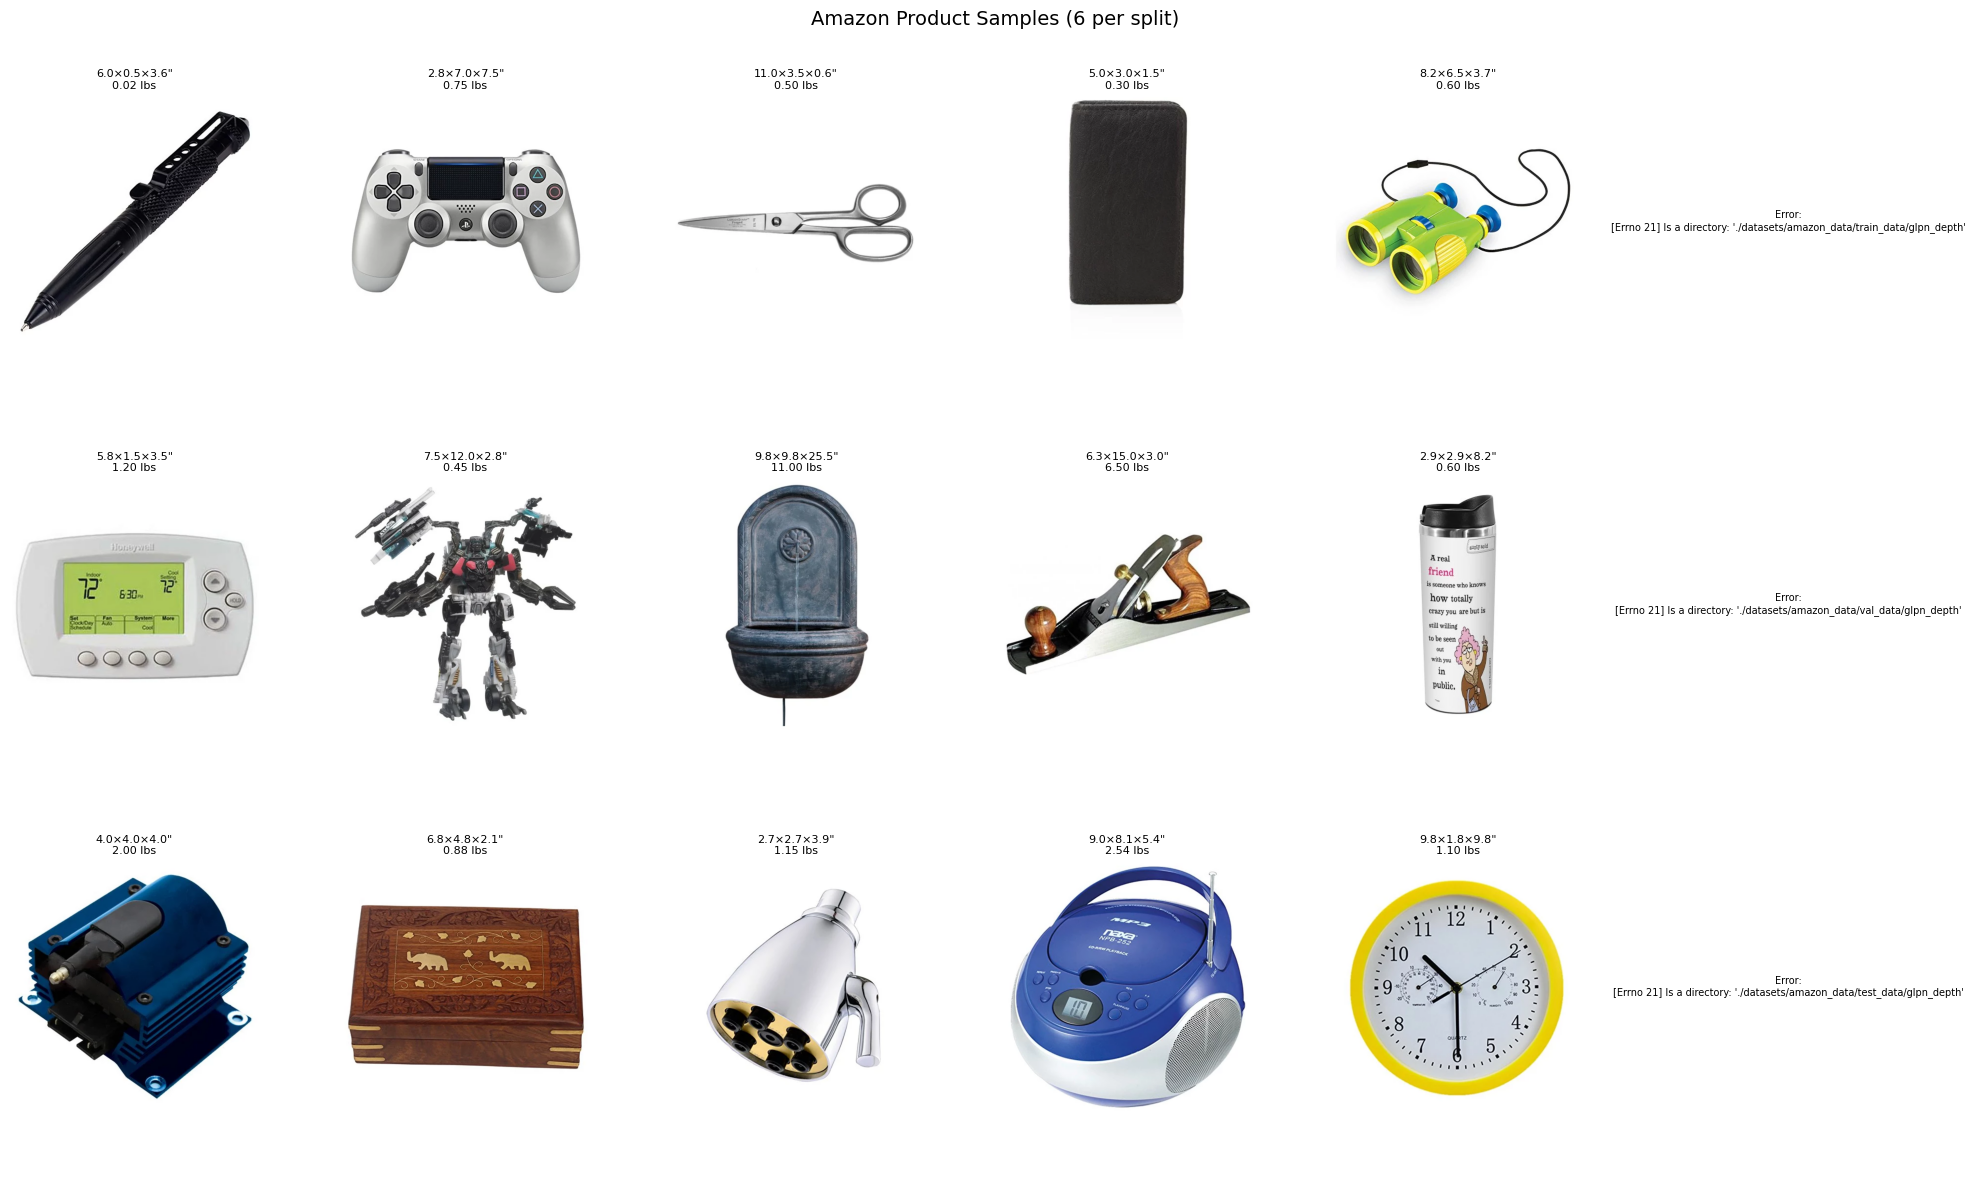

In [21]:
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
splits = ['train_data', 'val_data', 'test_data']

for row, split in enumerate(splits):
    split_dir = os.path.join(AMAZON_DIR, split)
    split_files = sorted(os.listdir(split_dir))
    # Pick 6 evenly spaced samples
    indices = np.linspace(0, len(split_files) - 1, 6, dtype=int)
    
    for col, idx in enumerate(indices):
        fpath = os.path.join(split_dir, split_files[idx])
        try:
            rec = load_pklz(fpath)
            img = pklz_image(rec['image_data'])
            dims = rec['dimensions']
            wt = rec['weight']
            dim_str = '×'.join(f"{float(d):.1f}" for d in dims) + '"'
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{dim_str}\n{wt} lbs", fontsize=8)
        except Exception as e:
            axes[row, col].text(0.5, 0.5, f"Error:\n{e}", ha='center', va='center', fontsize=7)
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(f"{split}\n({len(split_files)} files)", fontsize=11)

plt.suptitle("Amazon Product Samples (6 per split)", fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Dataset Statistics (sampling for speed)

In [22]:
import random as rng

all_dims_amz = []
all_weights_amz = []
all_img_shapes = []
split_counts = {}

for split in ['train_data', 'val_data', 'test_data']:
    split_dir = os.path.join(AMAZON_DIR, split)
    split_files = sorted(os.listdir(split_dir))
    split_counts[split] = len(split_files)
    
    # Sample up to 200 files per split for speed
    sample_files = rng.sample(split_files, min(200, len(split_files)))
    
    for fname in sample_files:
        try:
            rec = load_pklz(os.path.join(split_dir, fname))
            dims_float = [float(d) for d in rec['dimensions']]
            all_dims_amz.append(dims_float)
            all_weights_amz.append(float(rec['weight']))
            img = pklz_image(rec['image_data'])
            all_img_shapes.append(img.shape)
        except:
            pass

all_dims_amz = np.array(all_dims_amz)
all_weights_amz = np.array(all_weights_amz)

print("=== Amazon Dataset Summary ===")
for split, count in split_counts.items():
    print(f"  {split}: {count} files")
print(f"  Total: {sum(split_counts.values())} files")

print(f"\nSampled {len(all_dims_amz)} products for statistics:")
print(f"\nImage shapes (unique): {set(tuple(s) for s in all_img_shapes)}")

print(f"\nDimensions (inches):")
for i, label in enumerate(['Width', 'Height', 'Depth']):
    print(f"  {label}: min={all_dims_amz[:,i].min():.2f}, max={all_dims_amz[:,i].max():.2f}, mean={all_dims_amz[:,i].mean():.2f}")

print(f"\nWeight (lbs):")
print(f"  min={all_weights_amz.min():.3f}, max={all_weights_amz.max():.3f}, mean={all_weights_amz.mean():.3f}")

# Bounding box diagonals for normalization comparison
dims_m_amz = all_dims_amz * 0.0254  # inches to meters
diags_amz = np.linalg.norm(dims_m_amz, axis=1)
print(f"\nBounding box diagonal (meters) — normalization factor:")
print(f"  min={diags_amz.min():.4f}, max={diags_amz.max():.4f}, mean={diags_amz.mean():.4f}")

/var/folders/w8/l3b5rp5n4vqdlhzzjgztff500000gq/T/ipykernel_92123/540533676.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(decompressed)


=== Amazon Dataset Summary ===
  train_data: 141951 files
  val_data: 6530 files
  test_data: 1436 files
  Total: 149917 files

Sampled 600 products for statistics:

Image shapes (unique): {(512, 512, 3)}

Dimensions (inches):
  Width: min=0.31, max=30.00, mean=8.53
  Height: min=0.39, max=28.50, mean=5.98
  Depth: min=0.30, max=25.00, mean=5.66

Weight (lbs):
  min=0.020, max=14.000, mean=2.094

Bounding box diagonal (meters) — normalization factor:
  min=0.0457, max=1.0616, mean=0.3253


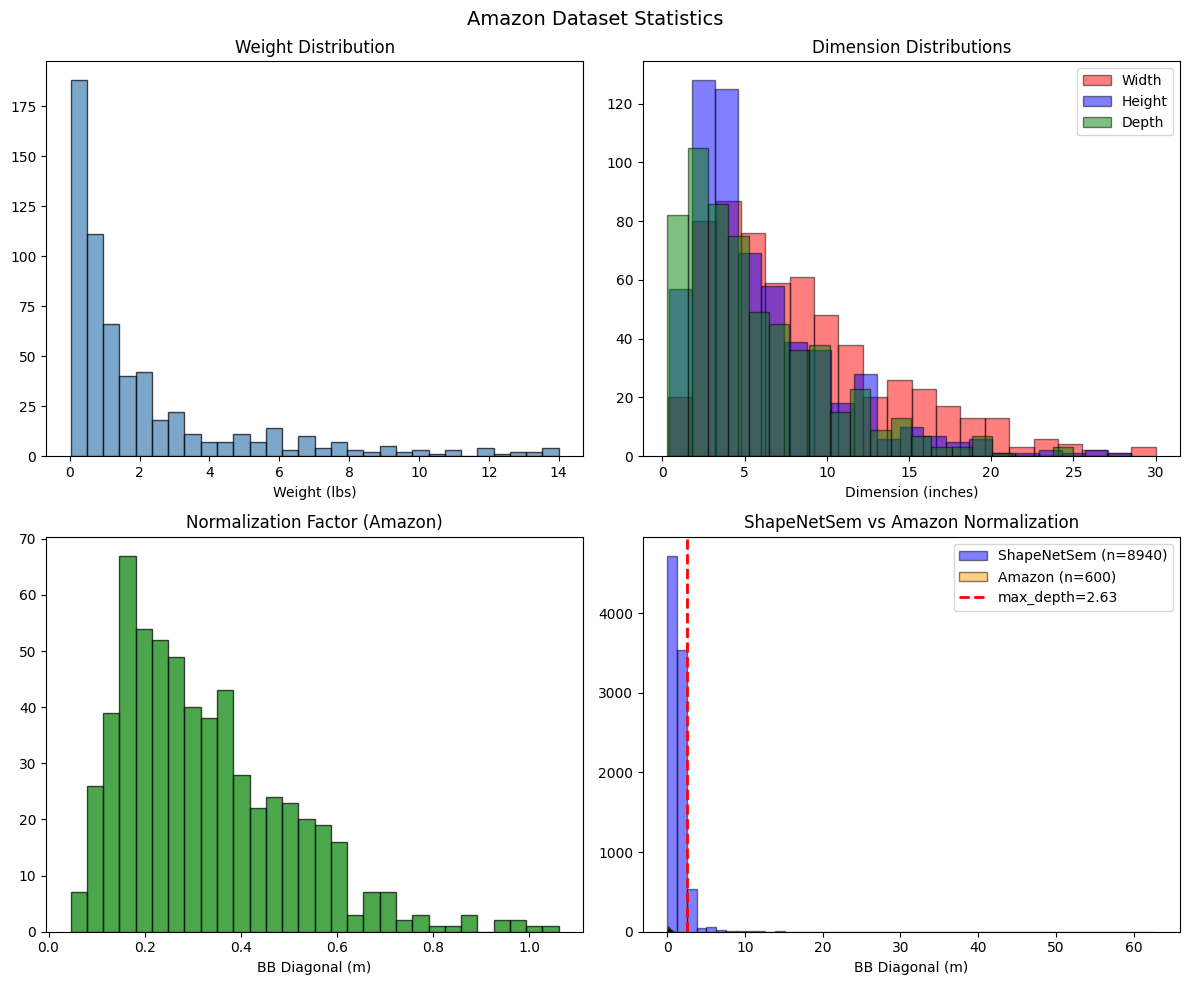

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(all_weights_amz, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Weight (lbs)')
axes[0, 0].set_title('Weight Distribution')

for i, (label, color) in enumerate(zip(['Width', 'Height', 'Depth'], ['red', 'blue', 'green'])):
    axes[0, 1].hist(all_dims_amz[:, i], bins=20, alpha=0.5, label=label, color=color, edgecolor='black')
axes[0, 1].set_xlabel('Dimension (inches)')
axes[0, 1].set_title('Dimension Distributions')
axes[0, 1].legend()

axes[1, 0].hist(diags_amz, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('BB Diagonal (m)')
axes[1, 0].set_title('Normalization Factor (Amazon)')

# Compare ShapeNetSem vs Amazon normalization factors
axes[1, 1].hist(all_diags, bins=50, alpha=0.5, label=f'ShapeNetSem (n={len(all_diags)})', color='blue', edgecolor='black')
axes[1, 1].hist(diags_amz, bins=30, alpha=0.5, label=f'Amazon (n={len(diags_amz)})', color='orange', edgecolor='black')
axes[1, 1].axvline(x=2.63, color='red', linestyle='--', linewidth=2, label='max_depth=2.63')
axes[1, 1].set_xlabel('BB Diagonal (m)')
axes[1, 1].set_title('ShapeNetSem vs Amazon Normalization')
axes[1, 1].legend()

plt.suptitle("Amazon Dataset Statistics", fontsize=14)
plt.tight_layout()
plt.show()

### 2.5 Inference Preprocessing Preview
Shows how an Amazon image gets resized (480×480) and padded (480×640) with white borders before feeding to the model.

/var/folders/w8/l3b5rp5n4vqdlhzzjgztff500000gq/T/ipykernel_92123/540533676.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.loads(decompressed)


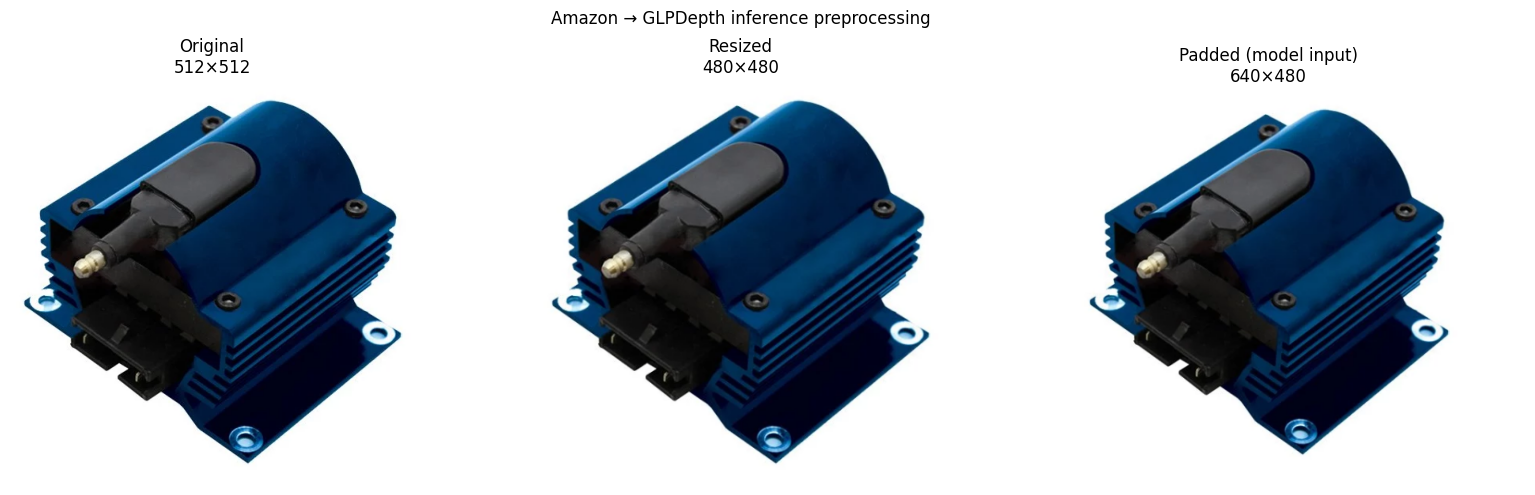

In [24]:
# Load a test sample and show preprocessing steps
rec = load_pklz(os.path.join(AMAZON_DIR, 'test_data', test_files[0]))
img_orig = pklz_image(rec['image_data'])

# Step 1: Resize to 480x480
img_resized = cv2.resize(img_orig, (480, 480))

# Step 2: Pad to 480x640 with white borders (80px each side)
img_padded = np.full((480, 640, 3), 255, dtype=np.uint8)
border = (640 - 480) // 2
img_padded[:, border:border+480, :] = img_resized

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_orig)
axes[0].set_title(f"Original\n{img_orig.shape[1]}×{img_orig.shape[0]}")
axes[1].imshow(img_resized)
axes[1].set_title(f"Resized\n480×480")
axes[2].imshow(img_padded)
axes[2].set_title(f"Padded (model input)\n640×480")
for ax in axes:
    ax.axis('off')
plt.suptitle("Amazon → GLPDepth inference preprocessing", fontsize=12)
plt.tight_layout()
plt.show()